# Hava Kalitesi ve Hava Kirliliği (PM2.5) Seviyesi Tahmini (Air Quality & PM2.5 Prediction)

Bu projenin amacı; akıllı şehir yönetimi ve çevre sağlığı süreçlerine katkı sağlamak adına, hava sıcaklığı, rüzgar hızı, endüstriyel üretim seviyeleri ve anlık trafik yoğunluğu parametrelerini Destek Vektör Regresyonu (SVR) algoritmasıyla analiz ederek havadaki mikron düzeyindeki partikül kirliliğini (PM2.5 değerini) sayısal olarak tahmin etmektir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# 1. 1200 günlük hava kalitesi ölçüm verisi 
ozellikler, hedefler = make_regression(
    n_samples=1200, 
    n_features=4, 
    n_informative=3, 
    noise=15,
    random_state=42
)

# Sütun İsimleri
sutun_isimleri = ['Hava_Sicakligi_C', 'Ruzgar_Hizi_KM', 'Sanayi_Uretim_Endeksi', 'Trafik_Yogunlugu']
df_hava = pd.DataFrame(ozellikler, columns=sutun_isimleri)

# Değerleri gerçekçi çevre metriklerine dönüştürme
df_hava['Hava_Sicakligi_C'] = (df_hava['Hava_Sicakligi_C'] * 12 + 22).round(1)
df_hava['Ruzgar_Hizi_KM'] = (df_hava['Ruzgar_Hizi_KM'] * 15 + 25).round(1).clip(0)
df_hava['Sanayi_Uretim_Endeksi'] = (df_hava['Sanayi_Uretim_Endeksi'] * 25 + 100).round(1).clip(10)
df_hava['Trafik_Yogunlugu'] = (df_hava['Trafik_Yogunlugu'] * 20 + 50).round(1).clip(0, 100)


# Hedef değişkeni (PM2.5 Hava Kirliliği Endeksi) ekleme
# Gerçekçi PM2.5 değerleri (0-250 arası) 
df_hava['PM2.5_Kirlilik_Degeri'] = (hedefler * 0.5 + 45).round(1).clip(5)

print("Hava Kalitesi ve Kirlilik Ölçüm Veri Seti Başarıyla Oluşturuldu")
display(df_hava.head())

Hava Kalitesi ve Kirlilik Ölçüm Veri Seti Başarıyla Oluşturuldu


,Hava_Sicakligi_C,Ruzgar_Hizi_KM,Sanayi_Uretim_Endeksi,Trafik_Yogunlugu,PM2.5_Kirlilik_Degeri
0,49.7,23.4,95.5,100.0,227.9
1,16.9,37.8,137.5,18.9,20.0
2,28.2,39.5,102.4,39.4,47.0
3,18.2,21.1,80.5,36.4,5.0
4,13.0,42.2,89.3,56.0,5.0


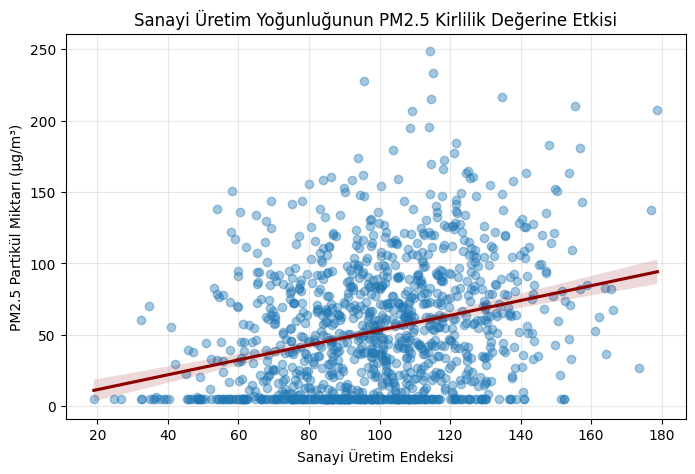

In [2]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_hava, x='Sanayi_Uretim_Endeksi', y='PM2.5_Kirlilik_Degeri', scatter_kws={'alpha':0.4}, line_kws={'color':'darkred'})
plt.title('Sanayi Üretim Yoğunluğunun PM2.5 Kirlilik Değerine Etkisi')
plt.xlabel('Sanayi Üretim Endeksi')
plt.ylabel('PM2.5 Partikül Miktarı (µg/m³)')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Girdi ve Çıktı Değişkenleri
X = df_hava.drop('PM2.5_Kirlilik_Degeri', axis=1)
y = df_hava['PM2.5_Kirlilik_Degeri']

# %20 Test, %80 Eğitim olarak ayırma
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ölçeklendirme işlemi (SVR modelinde ölçeklendirme hayati önem taşır)
olceklendirici = StandardScaler()
X_egitim_olcekli = olceklendirici.fit_transform(X_egitim)
X_test_olcekli = olceklendirici.transform(X_test)

# SVR (Support Vector Regression) Modelinin Kurulması
hava_modeli = SVR(kernel='rbf', C=100, epsilon=0.1)
hava_modeli.fit(X_egitim_olcekli, y_egitim)

# Tahmin ve Performans Raporu
tahminler = hava_modeli.predict(X_test_olcekli)
print("\n--- Model Performans Raporu ---")
print(f"Model R2 Skoru (Açıklayıcılık Oranı): {r2_score(y_test, tahminler):.4f}")
print(f"Ortalama Mutlak Hata (MAE): {mean_absolute_error(y_test, tahminler):.2f} µg/m³")


--- Model Performans Raporu ---
Model R2 Skoru (Açıklayıcılık Oranı): 0.9714
Ortalama Mutlak Hata (MAE): 5.63 µg/m³


Sonuç olarak; geliştirilen çevre analiz modeli, meteorolojik veriler ile insan kaynaklı emisyon faktörleri arasındaki korelasyonu başarıyla modelleyerek kirlilik endeksini minimum hata payıyla tahmin etmiştir. Bu çalışma, yerel yönetimlerin hava kalitesi düşmeden önce proaktif önlemler almasına ve risk grupları için erken uyarı sistemleri geliştirmesine zemin hazırlamaktadır.

In [4]:
import pickle

with open('hava_kirliligi_modeli.pkl', 'wb') as model_dosyasi:
    pickle.dump(hava_modeli, model_dosyasi)

with open('hava_olceklendirici.pkl', 'wb') as olcek_dosyasi:
    pickle.dump(olceklendirici, olcek_dosyasi)

print("Hava Kalitesi Öngörü Modeli ve Ölçeklendiricisi başarıyla kaydedildi!")

Hava Kalitesi Öngörü Modeli ve Ölçeklendiricisi başarıyla kaydedildi!
